1. Обрати унікальний датасет з https://archive.ics.uci.edu/datasets , який відповідає 
наступним вимогам: 
a. Dataset Characteristics: Multivariate 
b. Attribute Characteristics: Categorical, Integer, Real 
c. Number of Attributes: at least 2 integers/real 
d. Has Missing Values: Yes 
Можна обрати датасет з інших ресурсів, але з цими ж вимогами. 
2. Здійснити Data Cleaning 
3. Побудувати графіки залежності одного integer/real атрибута від іншого (lineplot, 
scatter etc). 
4. Побудувати гістограму по одному з атрибутів, що буде показувати на кількість 
елементів, що знаходяться у 5 діапазонах, які ви задасте. 
5. Збудувати 
графіки, 
використовуючи 
приклади, 
наведені 
у 
https://medium.com/data-science/the-art-of-effective-visualization-of-multi-dimension
al-data-6c7202990c57  
6. Побудувати інші графіки, що покажуть корисну інформацію про датасет. 
Загальна кількість графіків має становити 5-8. 

Перші рядки:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      

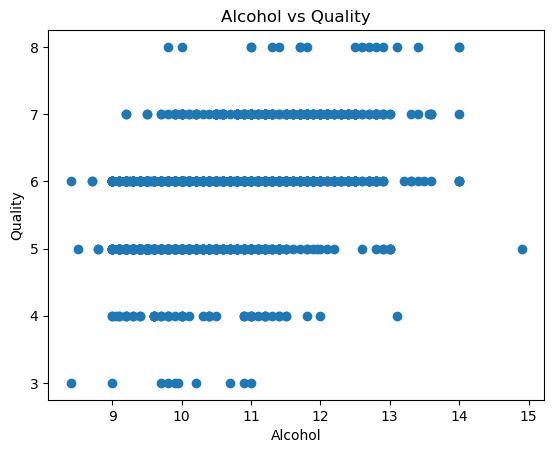

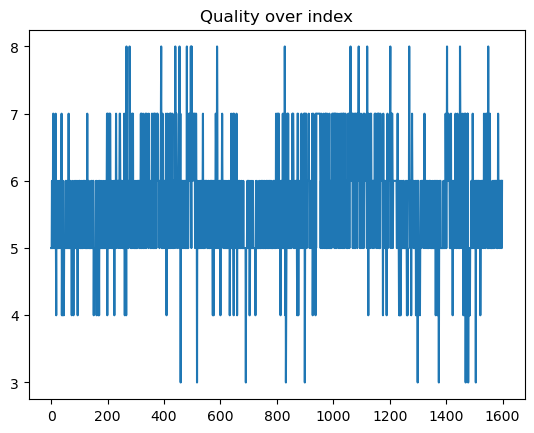

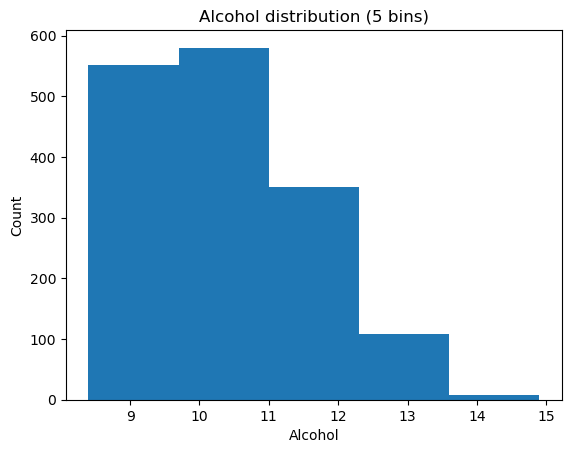

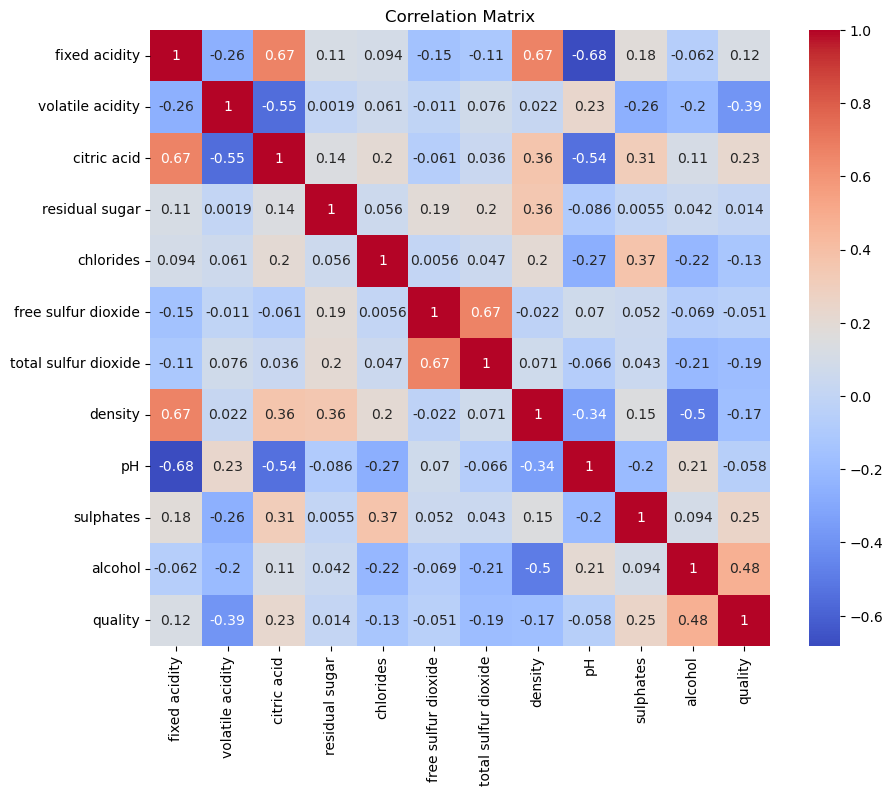

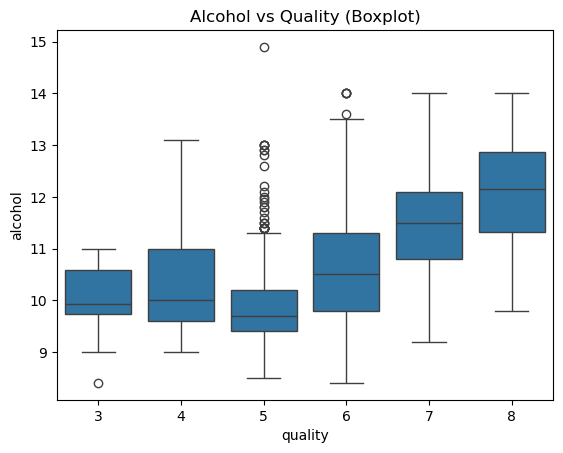

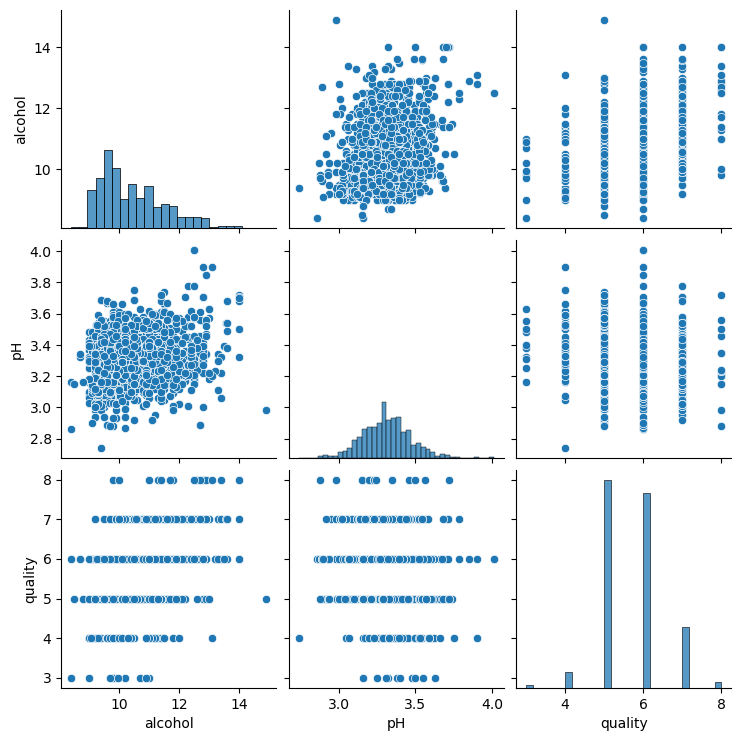

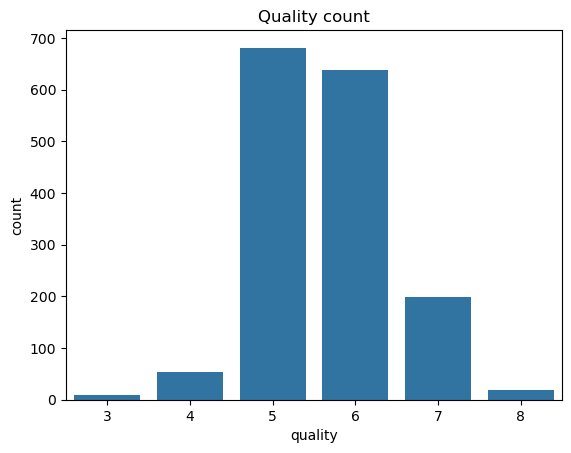

In [1]:

!pip install pandas matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# ЗАВАНТАЖЕННЯ ДАННИХ

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

print("Перші рядки:")
print(df.head())

print("\nІнформація:")
print(df.info())

print("\nОпис:")
print(df.describe())

# DATA CLEANING

print("\nПропуски ДО:")
print(df.isnull().sum())

df.iloc[0, 0] = np.nan

# заповняю середнім
df.fillna(df.mean(), inplace=True)

print("\nПропуски ПІСЛЯ:")
print(df.isnull().sum())

# 1. SCATTER PLOT

plt.figure()
plt.scatter(df['alcohol'], df['quality'])
plt.xlabel('Alcohol')
plt.ylabel('Quality')
plt.title('Alcohol vs Quality')
plt.show()

# 2. LINE PLOT

plt.figure()
df['quality'].plot()
plt.title('Quality over index')
plt.show()

# 3. HISTOGRAM 

plt.figure()
plt.hist(df['alcohol'], bins=5)
plt.title('Alcohol distribution (5 bins)')
plt.xlabel('Alcohol')
plt.ylabel('Count')
plt.show()

# 4. CORRELATION MATRIX

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# 5. BOXPLOT

plt.figure()
sns.boxplot(x=df['quality'], y=df['alcohol'])
plt.title('Alcohol vs Quality (Boxplot)')
plt.show()

# 6. PAIRPLOT

sns.pairplot(df[['alcohol', 'pH', 'quality']])
plt.show()

# 7. COUNTPLOT

plt.figure()
sns.countplot(x='quality', data=df)
plt.title('Quality count')
plt.show()
